# 03 — Evaluación Avanzada del Modelo

Tras la Reestructuración de Negocio (unificando `CONGELADA` y `DESERTOR` en `BAJA_RETENCION`), evaluaremos exhaustivamente la capacidad de generalización del Random Forest utilizando Validación Cruzada y métricas probabilísticas (Curvas ROC Multiclase).

In [1]:
%load_ext kedro.ipython

[05/15/26 15:36:39] INFO     Using                                                                  ]8;id=3543316;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=3543317;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#275\275]8;;\
                             '/Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/py                
                             thon3.12/site-packages/kedro/framework/project/rich_logging.yml' as                   
                             logging configuration.                                                                

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=3543324;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=3543325;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=3543331;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=3543332;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=3543338;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=3543339;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#181\181]8;;\
                             /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe.                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[05/15/26 15:36:39] INFO     No typed parameter requirements found, returning original   ]8;id=3543346;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py\parameter_validator.py]8;;\:]8;id=3543347;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py#108\108]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=3543354;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=3543355;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro_telemetry/plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[05/15/26 15:36:40] INFO     Kedro project ev_parcial1_uribe                                        ]8;id=3543361;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=3543362;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=3543368;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=3543369;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc, roc_auc_score

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").is_file() and (PROJECT_ROOT.parent / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "03_primary" / "tabla_maestra.csv"


## 1. Carga y Preparación de Datos (Unificación de Clases)

In [3]:
df = pd.read_csv(DATA_PATH)

# Unificación de Clases para evitar Data Starvation
df['estado_matricula'] = df['estado_matricula'].replace(['CONGELADA', 'DESERTOR'], 'BAJA_RETENCION')

num_cols = ["total_ausencias", "promedio_notas", "semestre"]
cat_cols = ["carrera", "sede"]
target_col = "estado_matricula"

df_ml = df.dropna(subset=num_cols + cat_cols + [target_col]).copy()

X = df_ml[num_cols + cat_cols]
y = df_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 2. Pipeline con ColumnTransformer y Random Forest
Garantizamos que la validación cruzada no sufra fuga de datos al integrar el preprocesamiento dentro del flujo.

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

## 3. Validación Cruzada (CV=5)

In [5]:
cv_results = cross_validate(rf_pipeline, X_train, y_train, cv=5, scoring=['f1_macro', 'accuracy'])
print(f"F1-Macro Promedio (5 Folds): {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")
print(f"Accuracy Promedio (5 Folds): {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")

F1-Macro Promedio (5 Folds): 0.6913 (+/- 0.0656)
Accuracy Promedio (5 Folds): 0.7760 (+/- 0.0411)


## 4. Curvas ROC Multiclase (One-vs-Rest)

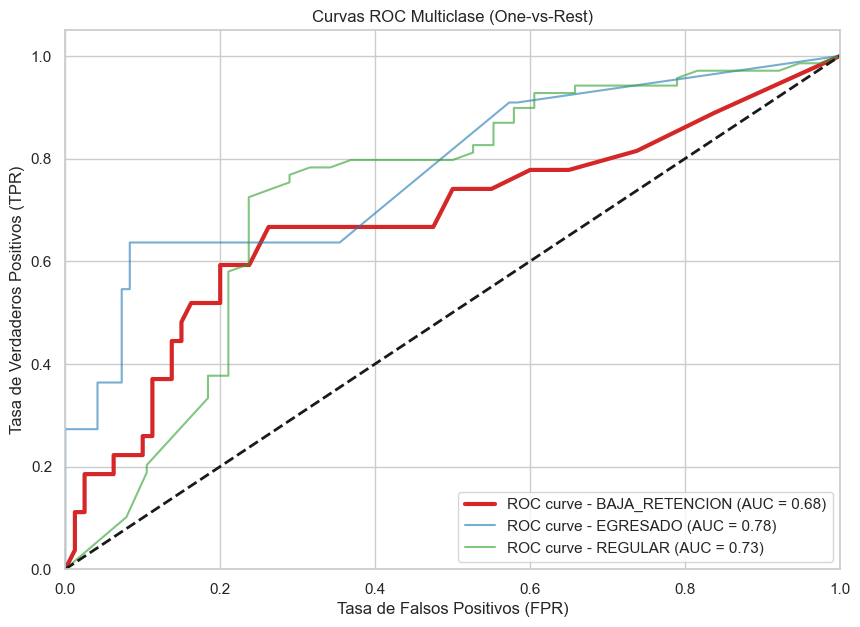

In [6]:
# Entrenamos el pipeline en todo el conjunto de entrenamiento para visualizar las curvas en test
rf_pipeline.fit(X_train, y_train)

# Predecir probabilidades
y_score = rf_pipeline.predict_proba(X_test)
classes = rf_pipeline.classes_

# Binarizar las etiquetas reales
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 7))
colors = ['#d62728', '#1f77b4', '#2ca02c'] # Red for BAJA_RETENCION, blue/green for others

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Destacar BAJA_RETENCION en la gráfica
    lw = 3 if classes[i] == 'BAJA_RETENCION' else 1.5
    alpha = 1.0 if classes[i] == 'BAJA_RETENCION' else 0.6
    
    plt.plot(fpr, tpr, color=color, lw=lw, alpha=alpha,
             label=f'ROC curve - {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()